## VALIDACIÓN DE WEIGHTED K-MEDOIDS (W-KMedoids)

### INICIALIZACIÓN: De Weight Manager y clases de K-Medoids

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import json
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

from src.clustering.traditional import KMedoids
from src.clustering.weighted import WKMedoids
from src.weighting.weight_manager import WeightManager
from src.evaluation import calculate_metrics
from src.utils.constants import PROCESSED_DATA_PATH

sns.set_style('whitegrid')
np.random.seed(42)

# Helper: Función auxiliar para crear instancias de Weight Manager para pruebas
        # Facilmente modificables sin necesidad de persistirlo
def make_temp_weight_manager(weights_dict: dict) -> WeightManager:
    tmp = tempfile.NamedTemporaryFile(suffix='.json', delete=False, mode='w', encoding='utf-8')
    json.dump({'features': weights_dict, 'metadata': {}}, tmp)
    tmp.close()
    return WeightManager(weight_path_=tmp.name)

def get_weighted_X(X: pd.DataFrame, weight_manager) -> pd.DataFrame:
    weights = weight_manager.get_weights_array(feature_order=X.columns.tolist())
    return X * weights

print('='*70)
print('VALIDACIÓN W-KMEDOIDS')
print('='*70)

VALIDACIÓN W-KMEDOIDS


### ESCENARIOS DE PRUEBA

#### PRUEBA 1: VERIFICACIÓN DE INFLUENCIA DE PESOS EN CALCULO DE DISTANCIAS
Dataset de 2 features: `feature_1` contiene señal real, `feature_2` es ruido puro. Se asignan distintos pesos, la inercia refleja distinta agrupación.


PRUEBA 1: VERIFICACIÓN DE APLICACIÓN DE PESOS

✓ Dataset generado: 200 muestras, 2 features
  feature_1: señal real (2 clusters separados, std=0.5)
  feature_2: poco relevante (std=6, varianza dominante)
Pesos cargados desde C:\Users\pabli\AppData\Local\Temp\tmp75yi8ahr.json, total de características: 2.

  Pesos asignados:
    feature_1 = 1.00  (Dominante)
    feature_2 = 0.2  (poco relevante)
Entrenando K-Medoids con 2 clusters...
✓ K-Medoids entrenado: 2 clusters identificados
  Inercia: 1007.9130
Calculando métricas de validación...
  Muestras: 200
  Clusters: 2
  ✓ Silhouette Score: 0.2005
  ✓ Davies-Bouldin Index: 2.3210
  ✓ Calinski-Harabasz Index: 23.3748
Entrenando Weighted K-Medoids con 2 clusters...
✓ WK-Medoids entrenado: 2 clusters identificados
  Inercia: 435.5115
Calculando métricas de validación...
  Muestras: 200
  Clusters: 2
  ✓ Silhouette Score: 0.2005
  ✓ Davies-Bouldin Index: 2.3210
  ✓ Calinski-Harabasz Index: 23.3748

✓ RESULTADOS:
  Métrica                    

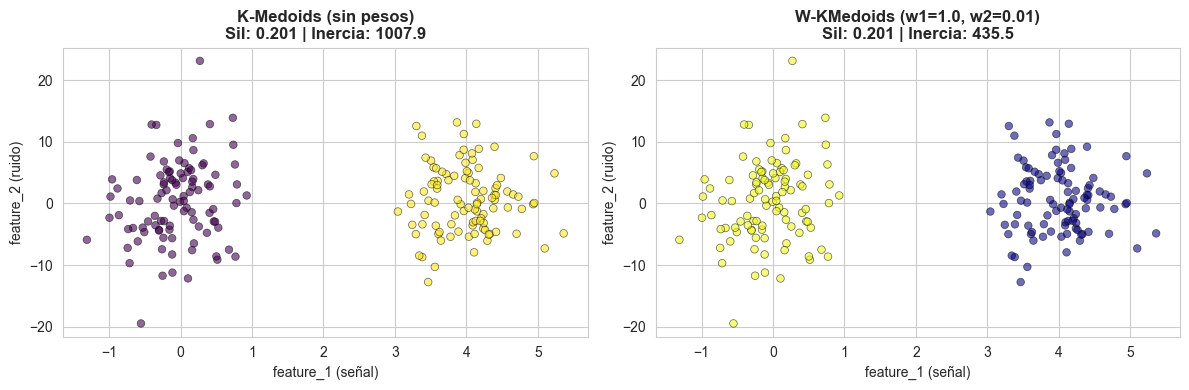

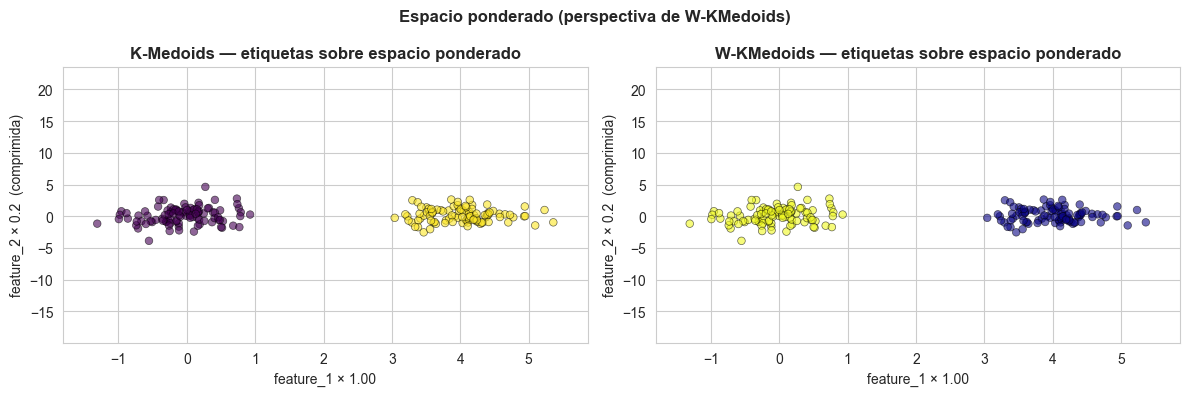

  En el espacio ponderado feature_2 queda casi colapsada al eje,
  revelando la separación real que guió al algoritmo.


In [2]:
print('\n' + '='*70)
print('PRUEBA 1: VERIFICACIÓN DE APLICACIÓN DE PESOS')
print('='*70)

# Generación del dataset
np.random.seed(42)
n = 200

f1 = np.concatenate([np.random.normal(0, 0.5, n//2), np.random.normal(4, 0.5, n//2)])
f2 = np.random.normal(0, 6, n)  

df_p1 = pd.DataFrame({'feature_1': f1, 'feature_2': f2})

print(f'\n✓ Dataset generado: {df_p1.shape[0]} muestras, {df_p1.shape[1]} features')
print(f'  feature_1: señal real (2 clusters separados, std=0.5)')
print(f'  feature_2: poco relevante (std=6, varianza dominante)')

# Ponderación
wm_p1 = make_temp_weight_manager({'feature_1': 1.0, 'feature_2': 0.2})

print(f'\n  Pesos asignados:')
print(f'    feature_1 = 1.00  (Dominante)')
print(f'    feature_2 = 0.2  (poco relevante)')

# Clustering
km_p1 = KMedoids(n_clusters=2, random_state=42)
km_p1.fit(df_p1)
metrics_km_p1 = calculate_metrics(df_p1, km_p1.labels_)

wkm_p1 = WKMedoids(n_clusters=2, random_state=42, weight_manager=wm_p1)
wkm_p1.fit(df_p1)
metrics_wkm_p1 = calculate_metrics(df_p1, wkm_p1.labels_)

print(f'\n✓ RESULTADOS:')
print(f"  {'Métrica':<25} {'K-Medoids':>12} {'W-KMedoids':>12}")
print(f"  {'-'*51}")
print(f"  {'Inercia':<25} {km_p1.inertia_:>12.4f} {wkm_p1.inertia_:>12.4f}")
print(f"  {'Silhouette':<25} {metrics_km_p1['silhouette']:>12.4f} {metrics_wkm_p1['silhouette']:>12.4f}")
print(f"  {'Davies-Bouldin':<25} {metrics_km_p1['davies_bouldin']:>12.4f} {metrics_wkm_p1['davies_bouldin']:>12.4f}")
print(f"  {'Calinski-Harabasz':<25} {metrics_km_p1['calinski_harabasz']:>12.4f} {metrics_wkm_p1['calinski_harabasz']:>12.4f}")


# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_p1['feature_1'], df_p1['feature_2'], c=km_p1.labels_,
                cmap='viridis', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[0].set_title(f'K-Medoids (sin pesos)\nSil: {metrics_km_p1["silhouette"]:.3f} | Inercia: {km_p1.inertia_:.1f}', fontweight='bold')
axes[0].set_xlabel('feature_1 (señal)')
axes[0].set_ylabel('feature_2 (ruido)')

axes[1].scatter(df_p1['feature_1'], df_p1['feature_2'], c=wkm_p1.labels_,
                cmap='plasma', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[1].set_title(f'W-KMedoids (w1=1.0, w2=0.01)\nSil: {metrics_wkm_p1["silhouette"]:.3f} | Inercia: {wkm_p1.inertia_:.1f}', fontweight='bold')
axes[1].set_xlabel('feature_1 (señal)')
axes[1].set_ylabel('feature_2 (ruido)')

plt.tight_layout()
plt.show()

print('\n' + '='*70)


# Visualización adicional: espacio ponderado (como lo ve W-KMedoids)
weights_p1 = wm_p1.get_weights_array(feature_order=df_p1.columns.tolist())
df_p1_weighted = df_p1 * weights_p1

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle('Espacio ponderado (perspectiva de W-KMedoids)', fontweight='bold', fontsize=12)

axes2[0].scatter(df_p1_weighted['feature_1'], df_p1_weighted['feature_2'], c=km_p1.labels_,
                cmap='viridis', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes2[0].set_title('K-Medoids — etiquetas sobre espacio ponderado', fontweight='bold')
axes2[0].set_xlabel('feature_1 × 1.00')
axes2[0].set_ylabel('feature_2 × 0.2  (comprimida)')

axes2[1].scatter(df_p1_weighted['feature_1'], df_p1_weighted['feature_2'], c=wkm_p1.labels_,
                cmap='plasma', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes2[1].set_title('W-KMedoids — etiquetas sobre espacio ponderado', fontweight='bold')
axes2[1].set_xlabel('feature_1 × 1.00')
axes2[1].set_ylabel('feature_2 × 0.2  (comprimida)')

x_lim = (df_p1['feature_1'].min() - 0.5, df_p1['feature_1'].max() + 0.5)
y_lim = (df_p1['feature_2'].min() - 0.5, df_p1['feature_2'].max() + 0.5)

axes2[0].set_xlim(x_lim)
axes2[0].set_ylim(y_lim)
axes2[1].set_xlim(x_lim)
axes2[1].set_ylim(y_lim)

plt.tight_layout()
plt.show()

print('  En el espacio ponderado feature_2 queda casi colapsada al eje,')
print('  revelando la separación real que guió al algoritmo.')

### PRUEBA 2: CARGA DEL ESQUEMA DE PONDERACIÓN REAL
WKMedoids operando con la ponderación generada desde constants.py. Se genera un dataset sintetico acorde a los valores reales

In [3]:
print('\n' + '='*70)
print('PRUEBA 2: CARGA DEL ESQUEMA DE PONDERACIÓN REAL')
print('='*70)

wm_real = WeightManager()
weights_dict = wm_real.get_weights()
feature_names = list(weights_dict.keys())
n_features = len(feature_names)

print(f'\n✓ WeightManager cargado: {n_features} características')
print(f'  Ruta: {wm_real.weights_path_}')
print(f'  Rango de pesos: [{min(weights_dict.values()):.2f}, {max(weights_dict.values()):.2f}]')

# Generación de dataset sintetico con las mismas caracteristicas
X_sintetico, y_sintetico = make_blobs(
    n_samples=500,
    n_features=n_features,
    centers=3,
    cluster_std=1.0,
    random_state=42
)
X_scaled = MinMaxScaler().fit_transform(X_sintetico)
df_p2 = pd.DataFrame(X_scaled, columns=feature_names)

print(f'\n✓ Dataset sintético: {df_p2.shape[0]} muestras, {df_p2.shape[1]} features')
print(f'  (Columnas = features del esquema electoral real)')

# Clustering
wkm_p2 = WKMedoids(n_clusters=3, random_state=42, weight_manager=wm_real)
wkm_p2.fit(df_p2)
metrics_wkm_p2 = calculate_metrics(df_p2, wkm_p2.labels_)

weights_arr = wm_real.get_weights_array(feature_order=feature_names)

print(f'\n✓ Verificación de pesos:')
print(f'  Array extraído: {len(weights_arr)} valores')
print(f'  Primeros 5 pesos: {[round(w, 2) for w in weights_arr[:5]]}')
print(f'  Corresponden a features: {feature_names[:5]}')

print(f'\n✓ RESULTADOS:')
print(f'  W-KMedoids: {wkm_p2.n_clusters_} clusters identificados')
print(f"  Silhouette:        {metrics_wkm_p2['silhouette']:.4f}")
print(f"  Davies-Bouldin:    {metrics_wkm_p2['davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz: {metrics_wkm_p2['calinski_harabasz']:.4f}")

print('\n' + '='*70)


PRUEBA 2: CARGA DEL ESQUEMA DE PONDERACIÓN REAL
Pesos cargados desde c:\electocluster\src\weighting\schemas\feature_weights.json, total de características: 42.

✓ WeightManager cargado: 42 características
  Ruta: c:\electocluster\src\weighting\schemas\feature_weights.json
  Rango de pesos: [0.50, 1.00]

✓ Dataset sintético: 500 muestras, 42 features
  (Columnas = features del esquema electoral real)
Entrenando Weighted K-Medoids con 3 clusters...
✓ WK-Medoids entrenado: 3 clusters identificados
  Inercia: 261.6100
Calculando métricas de validación...
  Muestras: 500
  Clusters: 3
  ✓ Silhouette Score: 0.7408
  ✓ Davies-Bouldin Index: 0.3772
  ✓ Calinski-Harabasz Index: 2367.7754

✓ Verificación de pesos:
  Array extraído: 42 valores
  Primeros 5 pesos: [1.0, 1.0, 0.75, 0.7, 0.7]
  Corresponden a features: ['edre', 'q10inc', 'etid', 'boletidnew', 'boletidnewb']

✓ RESULTADOS:
  W-KMedoids: 3 clusters identificados
  Silhouette:        0.7408
  Davies-Bouldin:    0.3772
  Calinski-Harab

### PRUEBA 3: COMPARATIVO K-MEDOIDS vs W-KMEDOIDS (ALTA DIMENSIONALIDAD)
Se compara ambos algoritmos sobre un dataset sintético de alta dimensionalidad similar al electoral (41 features). Se construyen grupos con features relevantes bien definidas y features de ruido. El objetivo es verificar que la ponderación produce una partición de mayor calidad cuando existe conocimiento diferencial de la importancia de características.


PRUEBA 3: COMPARATIVO K-MEDOIDS vs W-KMEDOIDS (ALTA DIMENSIONALIDAD)

✓ Dataset generado: 600 muestras, 42 features
  9 features con señal real + 33 features de ruido
  (Dimensionalidad equivalente al dataset electoral: 42 features)
Pesos cargados desde C:\Users\pabli\AppData\Local\Temp\tmpq9flrdnc.json, total de características: 42.

  Esquema de ponderación:
    9 features relevantes = 1.00
    33 features de ruido      = 0.05
Entrenando K-Medoids con 3 clusters...
✓ K-Medoids entrenado: 3 clusters identificados
  Inercia: 3779.0676
Calculando métricas de validación...
  Muestras: 600
  Clusters: 3
  ✓ Silhouette Score: 0.0210
  ✓ Davies-Bouldin Index: 5.1610
  ✓ Calinski-Harabasz Index: 16.2240
Entrenando Weighted K-Medoids con 3 clusters...
✓ WK-Medoids entrenado: 3 clusters identificados
  Inercia: 299.9024
Calculando métricas de validación...
  Muestras: 600
  Clusters: 3
  ✓ Silhouette Score: 0.0995
  ✓ Davies-Bouldin Index: 2.7844
  ✓ Calinski-Harabasz Index: 55.2919


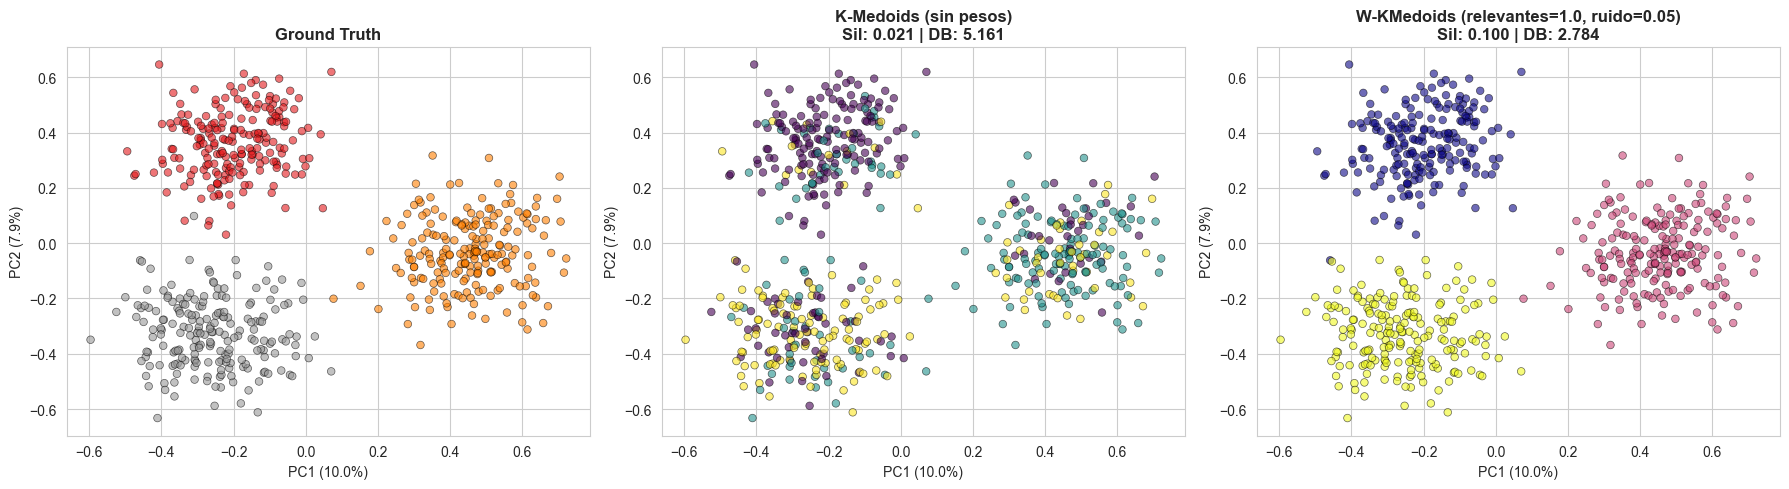

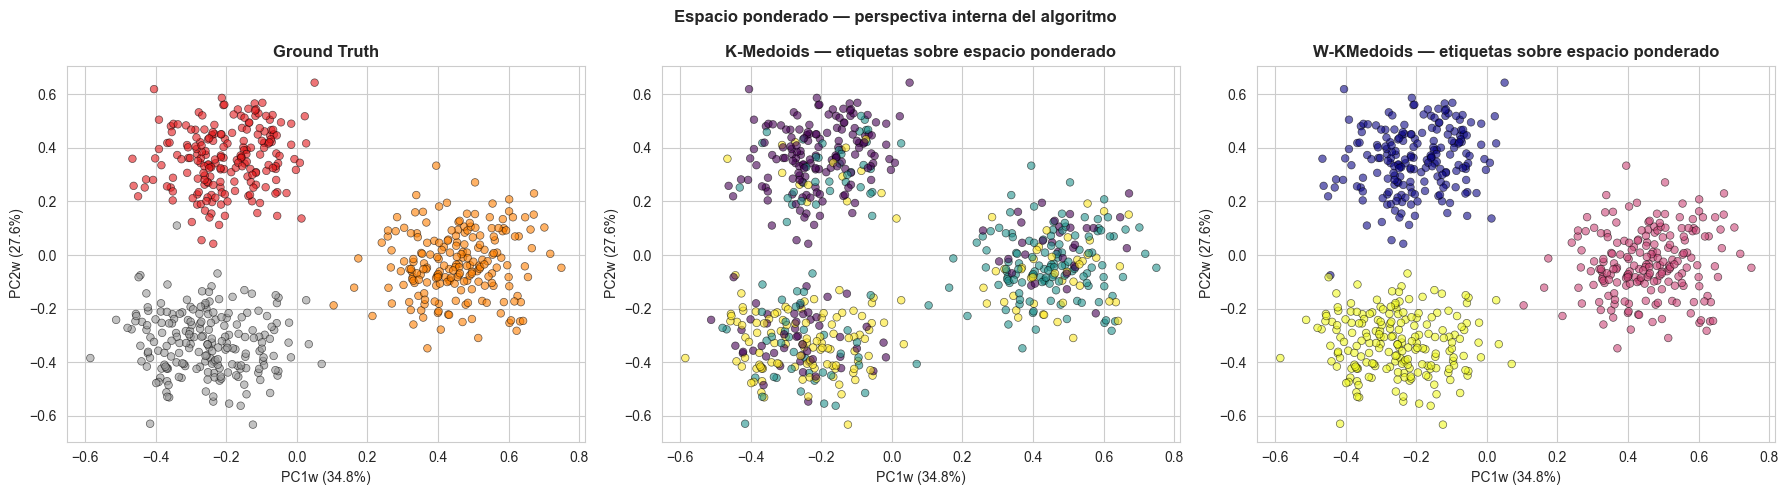


✓ RESULTADOS COMPARATIVOS:
  Algoritmo                        Silhouette   Davies-Bouldin     Calinski-H
  --------------------------------------------------------------------------
  K-Medoids (sin pesos)                0.0210           5.1610        16.2240
  W-KMedoids (con pesos)               0.0995           2.7844        55.2919

  Δ Silhouette: +0.0786
  ↑ Ponderación mejora la segmentación



In [4]:
print('\n' + '='*70)
print('PRUEBA 3: COMPARATIVO K-MEDOIDS vs W-KMEDOIDS (ALTA DIMENSIONALIDAD)')
print('='*70)

np.random.seed(42)
N_RELEVANTES = 9
N_RUIDO = 33   # total = 41, igual que el dataset electoral
N_SAMPLES = 600
N_CLUSTERS = 3

# Features relevantes: clusters bien definidos
X_rel, y_true = make_blobs(
    n_samples=N_SAMPLES,
    n_features=N_RELEVANTES,
    centers=N_CLUSTERS,
    cluster_std=3.5,
    random_state=42
)

# Features poco relevantes: alta varianza, sin estructura, tomadas como ruido para esta prueba
X_noise = np.random.normal(0, 2.0, (N_SAMPLES, N_RUIDO))

X_combined = np.hstack([X_rel, X_noise])
cols_rel   = [f'feat_relevante_{i+1}' for i in range(N_RELEVANTES)]
cols_ruido = [f'feat_ruido_{i+1}' for i in range(N_RUIDO)]
cols_all   = cols_rel + cols_ruido

df_p3 = pd.DataFrame(MinMaxScaler().fit_transform(X_combined), columns=cols_all)

print(f'\n✓ Dataset generado: {df_p3.shape[0]} muestras, {df_p3.shape[1]} features')
print(f'  {N_RELEVANTES} features con señal real + {N_RUIDO} features de ruido')
print(f'  (Dimensionalidad equivalente al dataset electoral: {N_RELEVANTES + N_RUIDO} features)')

# Pesos: features relevantes altas, ruido bajo
weights_p3 = {f: 1.0 for f in cols_rel}
weights_p3.update({f: 0.05 for f in cols_ruido})
wm_p3 = make_temp_weight_manager(weights_p3)

print(f'\n  Esquema de ponderación:')
print(f'    {N_RELEVANTES} features relevantes = 1.00')
print(f'    {N_RUIDO} features de ruido      = 0.05')

# K-Medoids tradicional
km_p3 = KMedoids(n_clusters=N_CLUSTERS, random_state=42)
km_p3.fit(df_p3)
metrics_km_p3 = calculate_metrics(df_p3, km_p3.labels_)

# W-KMedoids con pesos
wkm_p3 = WKMedoids(n_clusters=N_CLUSTERS, random_state=42, weight_manager=wm_p3)
wkm_p3.fit(df_p3)
metrics_wkm_p3 = calculate_metrics(df_p3, wkm_p3.labels_)


# Visualización con PCA 2D
pca_p3 = PCA(n_components=2, random_state=42)
X_2d_p3 = pca_p3.fit_transform(df_p3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_2d_p3[:, 0], X_2d_p3[:, 1], c=y_true, cmap='Set1',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[0].set_title('Ground Truth', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_p3.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_p3.explained_variance_ratio_[1]*100:.1f}%)')

axes[1].scatter(X_2d_p3[:, 0], X_2d_p3[:, 1], c=km_p3.labels_, cmap='viridis',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[1].set_title(f'K-Medoids (sin pesos)\nSil: {metrics_km_p3["silhouette"]:.3f} | DB: {metrics_km_p3["davies_bouldin"]:.3f}', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_p3.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_p3.explained_variance_ratio_[1]*100:.1f}%)')

axes[2].scatter(X_2d_p3[:, 0], X_2d_p3[:, 1], c=wkm_p3.labels_, cmap='plasma',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[2].set_title(f'W-KMedoids (relevantes=1.0, ruido=0.05)\nSil: {metrics_wkm_p3["silhouette"]:.3f} | DB: {metrics_wkm_p3["davies_bouldin"]:.3f}', fontweight='bold')
axes[2].set_xlabel(f'PC1 ({pca_p3.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca_p3.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()

# Visualización espacio ponderado
weights_p3_arr = wm_p3.get_weights_array(feature_order=df_p3.columns.tolist())
df_p3_weighted = df_p3 * weights_p3_arr

pca_p3w = PCA(n_components=2, random_state=42)
X_2d_p3w = pca_p3w.fit_transform(df_p3_weighted)

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('Espacio ponderado — perspectiva interna del algoritmo', fontweight='bold', fontsize=12)

axes2[0].scatter(X_2d_p3w[:, 0], X_2d_p3w[:, 1], c=y_true, cmap='Set1',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes2[0].set_title('Ground Truth', fontweight='bold')
axes2[0].set_xlabel(f'PC1w ({pca_p3w.explained_variance_ratio_[0]*100:.1f}%)')
axes2[0].set_ylabel(f'PC2w ({pca_p3w.explained_variance_ratio_[1]*100:.1f}%)')

axes2[1].scatter(X_2d_p3w[:, 0], X_2d_p3w[:, 1], c=km_p3.labels_, cmap='viridis',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes2[1].set_title('K-Medoids — etiquetas sobre espacio ponderado', fontweight='bold')
axes2[1].set_xlabel(f'PC1w ({pca_p3w.explained_variance_ratio_[0]*100:.1f}%)')
axes2[1].set_ylabel(f'PC2w ({pca_p3w.explained_variance_ratio_[1]*100:.1f}%)')

axes2[2].scatter(X_2d_p3w[:, 0], X_2d_p3w[:, 1], c=wkm_p3.labels_, cmap='plasma',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes2[2].set_title('W-KMedoids — etiquetas sobre espacio ponderado', fontweight='bold')
axes2[2].set_xlabel(f'PC1w ({pca_p3w.explained_variance_ratio_[0]*100:.1f}%)')
axes2[2].set_ylabel(f'PC2w ({pca_p3w.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()

print(f'\n✓ RESULTADOS COMPARATIVOS:')
print(f"  {'Algoritmo':<30} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-H':>14}")
print(f"  {'-'*74}")
print(f"  {'K-Medoids (sin pesos)':<30} {metrics_km_p3['silhouette']:>12.4f} {metrics_km_p3['davies_bouldin']:>16.4f} {metrics_km_p3['calinski_harabasz']:>14.4f}")
print(f"  {'W-KMedoids (con pesos)':<30} {metrics_wkm_p3['silhouette']:>12.4f} {metrics_wkm_p3['davies_bouldin']:>16.4f} {metrics_wkm_p3['calinski_harabasz']:>14.4f}")

mejora = metrics_wkm_p3['silhouette'] - metrics_km_p3['silhouette']
print(f'\n  Δ Silhouette: {mejora:+.4f}')
print(f"  {'↑ Ponderación mejora la segmentación' if mejora > 0 else '— Particiones equivalentes en este escenario'}")

print('\n' + '='*70)



### PRUEBA 4: COMPARATIVO SOBRE DATASET ELECTORAL REAL
Ejecuta K-Medoids y W-KMedoids sobre el dataset electoral preprocesado y compara los resultados. Incluye métricas de validación, distribución de clusters y perfil de medoides.

#### K = 2


PRUEBA 4-A: COMPARATIVO SOBRE DATASET ELECTORAL REAL

✓ Dataset cargado: 1706 registros × 28 variables
  Missings: 0
Pesos cargados desde c:\electocluster\src\weighting\schemas\feature_weights.json, total de características: 42.
Entrenando K-Medoids con 2 clusters...
✓ K-Medoids entrenado: 2 clusters identificados
  Inercia: 8953.5881
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.1178
  ✓ Davies-Bouldin Index: 2.6546
  ✓ Calinski-Harabasz Index: 230.8875
Entrenando Weighted K-Medoids con 2 clusters...
✓ WK-Medoids entrenado: 2 clusters identificados
  Inercia: 2473.9323
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.0895
  ✓ Davies-Bouldin Index: 3.1401
  ✓ Calinski-Harabasz Index: 165.6935

✓ MÉTRICAS DE VALIDACIÓN:
  Algoritmo                        Silhouette   Davies-Bouldin     Calinski-H
  --------------------------------------------------------------------------
  K-Medoids (sin pesos)   

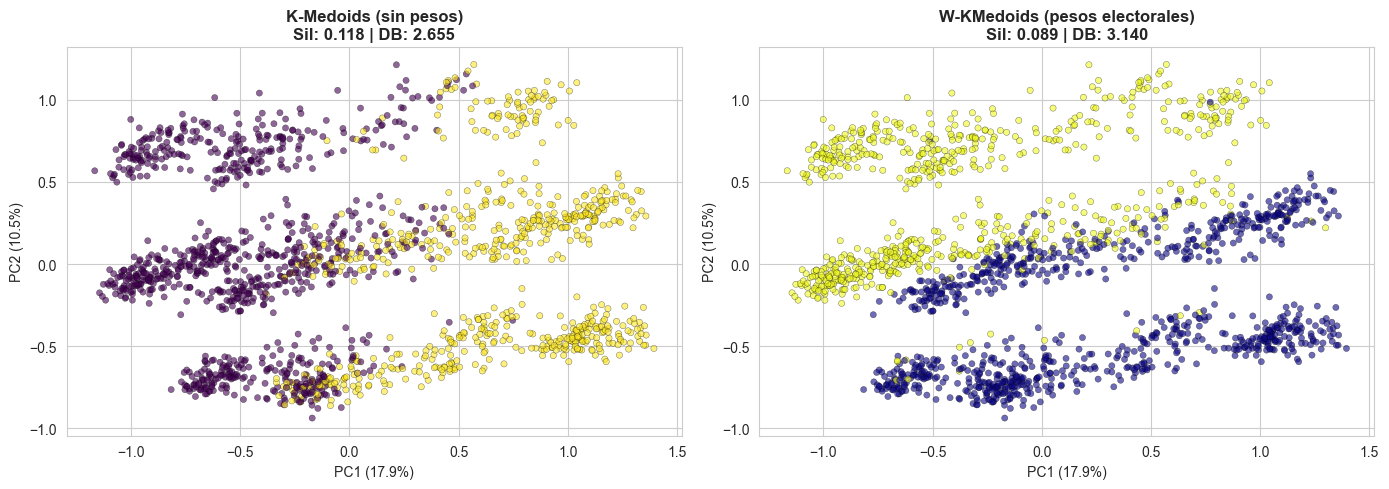

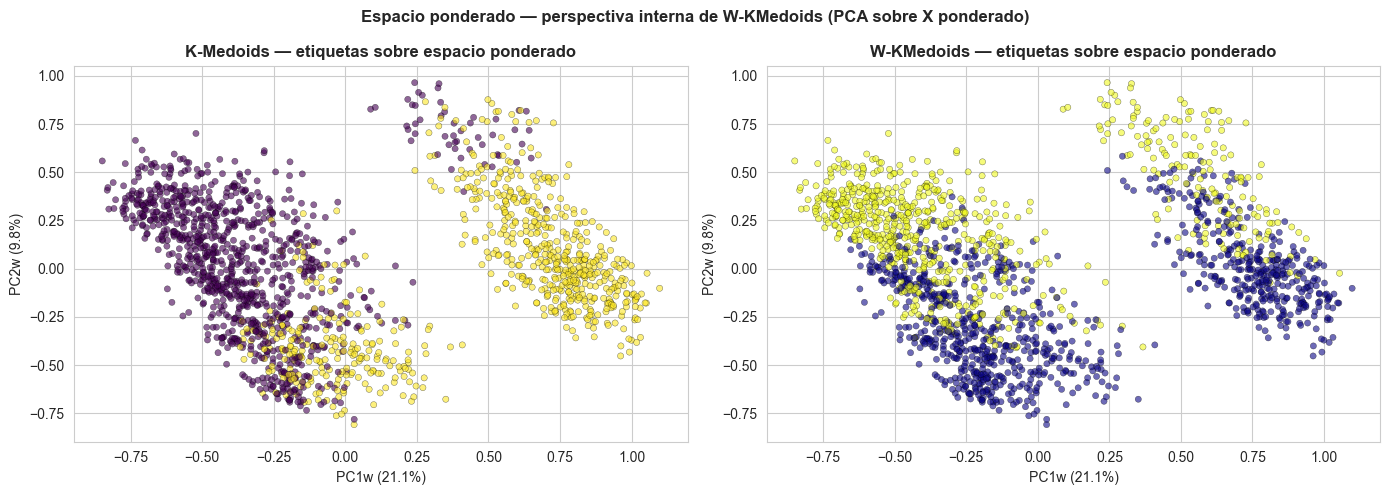

  Las características con mayor peso electoral dominan la proyección PCA.
  Comparar con el gráfico anterior muestra qué tanto influyeron los pesos
  en la geometría del espacio donde se tomaron las decisiones de clustering.


In [ ]:
print('\n' + '='*70)
print('PRUEBA 4-A: COMPARATIVO SOBRE DATASET ELECTORAL REAL')
print('='*70)

# Cargar dataset preprocesado
df_electoral = pd.read_csv(PROCESSED_DATA_PATH)

print(f'\n✓ Dataset cargado: {df_electoral.shape[0]} registros × {df_electoral.shape[1]} variables')
print(f'  Missings: {df_electoral.isnull().sum().sum()}')

# WeightManager con esquema electoral real cargado
wm_electoral = WeightManager()

# K-Medoids tradicional
km_p4A = KMedoids(n_clusters=2, random_state=42)
km_p4A.fit(df_electoral)
metrics_km_p4A = calculate_metrics(df_electoral, km_p4A.labels_)

# W-KMedoids
wkm_p4A = WKMedoids(n_clusters=2, random_state=42, weight_manager=wm_electoral)
wkm_p4A.fit(df_electoral)
metrics_wkm_p4A = calculate_metrics(df_electoral, wkm_p4A.labels_)

# Tabla comparativa de métricas
print(f'\n✓ MÉTRICAS DE VALIDACIÓN:')
print(f"  {'Algoritmo':<30} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-H':>14}")
print(f"  {'-'*74}")
print(f"  {'K-Medoids (sin pesos)':<30} {metrics_km_p4A['silhouette']:>12.4f} {metrics_km_p4A['davies_bouldin']:>16.4f} {metrics_km_p4A['calinski_harabasz']:>14.4f}")
print(f"  {'W-KMedoids (con pesos)':<30} {metrics_wkm_p4A['silhouette']:>12.4f} {metrics_wkm_p4A['davies_bouldin']:>16.4f} {metrics_wkm_p4A['calinski_harabasz']:>14.4f}")

# Distribución de clusters
print(f'\n✓ DISTRIBUCIÓN DE CLUSTERS:')
dist_km  = pd.Series(km_p4A.labels_).value_counts().sort_index()
dist_wkm = pd.Series(wkm_p4A.labels_).value_counts().sort_index()

print(f"  {'Cluster':<10} {'K-Medoids':>12} {'W-KMedoids':>12}")
print(f"  {'-'*36}")
for c in sorted(set(list(dist_km.index) + list(dist_wkm.index))):
    km_n  = dist_km.get(c, 0)
    wkm_n = dist_wkm.get(c, 0)
    print(f"  {c:<10} {km_n:>12} {wkm_n:>12}")

# Visualización PCA 2D
pca_p4 = PCA(n_components=2, random_state=42)
X_2d_p4 = pca_p4.fit_transform(df_electoral)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d_p4[:, 0], X_2d_p4[:, 1], c=km_p4A.labels_, cmap='viridis',
                alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes[0].set_title(f'K-Medoids (sin pesos)\nSil: {metrics_km_p4A["silhouette"]:.3f} | DB: {metrics_km_p4A["davies_bouldin"]:.3f}', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_p4.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_p4.explained_variance_ratio_[1]*100:.1f}%)')

axes[1].scatter(X_2d_p4[:, 0], X_2d_p4[:, 1], c=wkm_p4A.labels_, cmap='plasma',
                alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes[1].set_title(f'W-KMedoids (pesos electorales)\nSil: {metrics_wkm_p4A["silhouette"]:.3f} | DB: {metrics_wkm_p4A["davies_bouldin"]:.3f}', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_p4.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_p4.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()


# Visualización adicional: PCA sobre espacio ponderado (datos electorales reales)
weights_electoral_arr = wm_electoral.get_weights_array(feature_order=df_electoral.columns.tolist())
df_electoral_weighted = df_electoral * weights_electoral_arr

pca_p4w = PCA(n_components=2, random_state=42)
X_2d_p4w = pca_p4w.fit_transform(df_electoral_weighted)

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Espacio ponderado — perspectiva interna de W-KMedoids (PCA sobre X ponderado)',
              fontweight='bold', fontsize=12)

axes2[0].scatter(X_2d_p4w[:, 0], X_2d_p4w[:, 1], c=km_p4A.labels_, cmap='viridis',
                alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes2[0].set_title(f'K-Medoids — etiquetas sobre espacio ponderado', fontweight='bold')
axes2[0].set_xlabel(f'PC1w ({pca_p4w.explained_variance_ratio_[0]*100:.1f}%)')
axes2[0].set_ylabel(f'PC2w ({pca_p4w.explained_variance_ratio_[1]*100:.1f}%)')

axes2[1].scatter(X_2d_p4w[:, 0], X_2d_p4w[:, 1], c=wkm_p4A.labels_, cmap='plasma',
                alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes2[1].set_title(f'W-KMedoids — etiquetas sobre espacio ponderado', fontweight='bold')
axes2[1].set_xlabel(f'PC1w ({pca_p4w.explained_variance_ratio_[0]*100:.1f}%)')
axes2[1].set_ylabel(f'PC2w ({pca_p4w.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()

print('  Las características con mayor peso electoral dominan la proyección PCA.')
print('  Comparar con el gráfico anterior muestra qué tanto influyeron los pesos')
print('  en la geometría del espacio donde se tomaron las decisiones de clustering.')

#### K=3


PRUEBA 4-B: COMPARATIVO SOBRE DATASET ELECTORAL REAL

✓ Dataset cargado: 1706 registros × 28 variables
  Missings: 0
Pesos cargados desde c:\electocluster\src\weighting\schemas\feature_weights.json, total de características: 42.
Entrenando K-Medoids con 3 clusters...
✓ K-Medoids entrenado: 3 clusters identificados
  Inercia: 8349.5889
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 3
  ✓ Silhouette Score: 0.0712
  ✓ Davies-Bouldin Index: 3.1387
  ✓ Calinski-Harabasz Index: 154.1534
Entrenando Weighted K-Medoids con 3 clusters...
✓ WK-Medoids entrenado: 3 clusters identificados
  Inercia: 2291.1370
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 3
  ✓ Silhouette Score: 0.0984
  ✓ Davies-Bouldin Index: 2.8149
  ✓ Calinski-Harabasz Index: 200.4987

✓ MÉTRICAS DE VALIDACIÓN:
  Algoritmo                        Silhouette   Davies-Bouldin     Calinski-H
  --------------------------------------------------------------------------
  K-Medoids (sin pesos)   

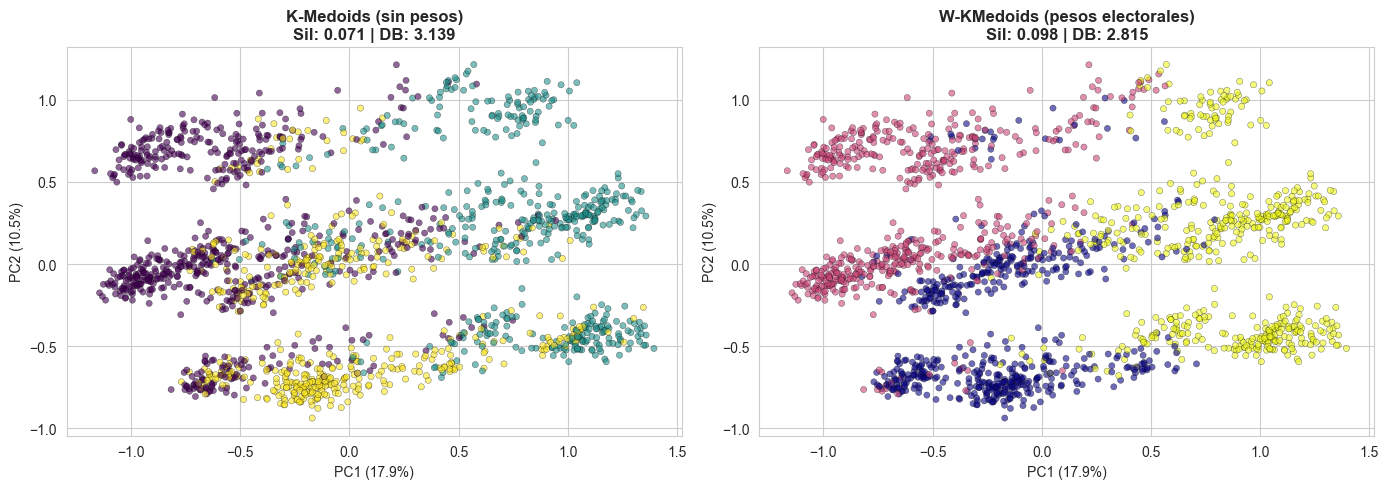

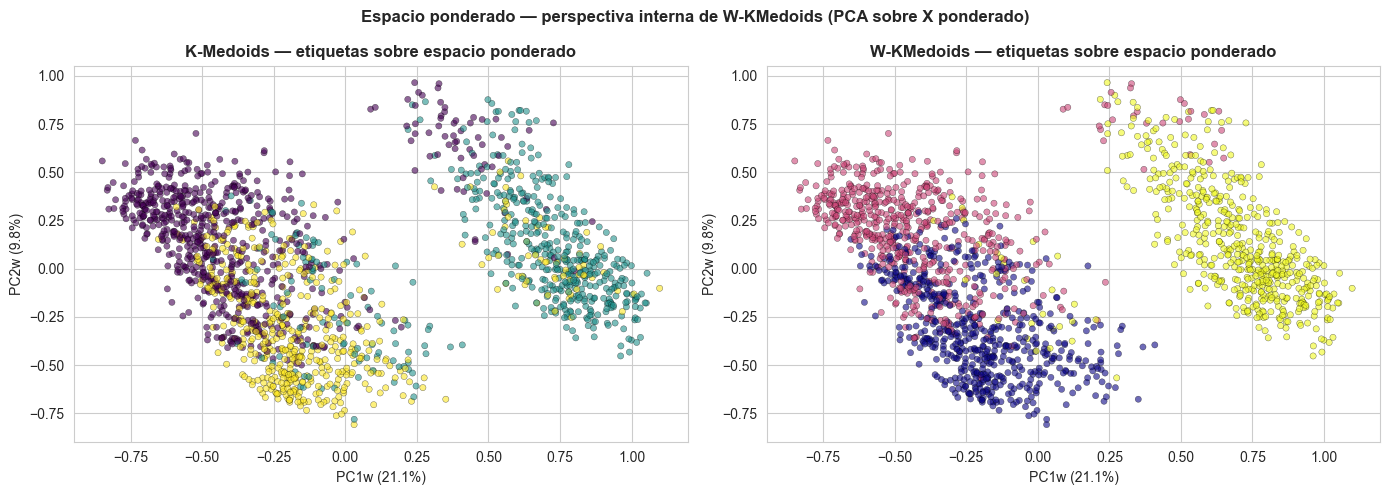

  Las características con mayor peso electoral dominan la proyección PCA.
  Comparar con el gráfico anterior muestra qué tanto influyeron los pesos
  en la geometría del espacio donde se tomaron las decisiones de clustering.


In [8]:
print('\n' + '='*70)
print('PRUEBA 4-B: COMPARATIVO SOBRE DATASET ELECTORAL REAL')
print('='*70)

# Cargar dataset preprocesado
df_electoral = pd.read_csv(PROCESSED_DATA_PATH)

print(f'\n✓ Dataset cargado: {df_electoral.shape[0]} registros × {df_electoral.shape[1]} variables')
print(f'  Missings: {df_electoral.isnull().sum().sum()}')

# WeightManager con esquema electoral real cargado
wm_electoral = WeightManager()

# Nota: Numero de clusters elegido es 3 para probar

# K-Medoids tradicional
km_p4 = KMedoids(n_clusters=3, random_state=42)
km_p4.fit(df_electoral)
metrics_km_p4 = calculate_metrics(df_electoral, km_p4.labels_)

# W-KMedoids
wkm_p4 = WKMedoids(n_clusters=3, random_state=42, weight_manager=wm_electoral)
wkm_p4.fit(df_electoral)
metrics_wkm_p4 = calculate_metrics(df_electoral, wkm_p4.labels_)

# Tabla comparativa de métricas
print(f'\n✓ MÉTRICAS DE VALIDACIÓN:')
print(f"  {'Algoritmo':<30} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-H':>14}")
print(f"  {'-'*74}")
print(f"  {'K-Medoids (sin pesos)':<30} {metrics_km_p4['silhouette']:>12.4f} {metrics_km_p4['davies_bouldin']:>16.4f} {metrics_km_p4['calinski_harabasz']:>14.4f}")
print(f"  {'W-KMedoids (con pesos)':<30} {metrics_wkm_p4['silhouette']:>12.4f} {metrics_wkm_p4['davies_bouldin']:>16.4f} {metrics_wkm_p4['calinski_harabasz']:>14.4f}")



# Distribución de clusters
print(f'\n✓ DISTRIBUCIÓN DE CLUSTERS:')
dist_km  = pd.Series(km_p4.labels_).value_counts().sort_index()
dist_wkm = pd.Series(wkm_p4.labels_).value_counts().sort_index()

print(f"  {'Cluster':<10} {'K-Medoids':>12} {'W-KMedoids':>12}")
print(f"  {'-'*36}")
for c in sorted(set(list(dist_km.index) + list(dist_wkm.index))):
    km_n  = dist_km.get(c, 0)
    wkm_n = dist_wkm.get(c, 0)
    print(f"  {c:<10} {km_n:>12} {wkm_n:>12}")

# Visualización PCA 2D
pca_p4 = PCA(n_components=2, random_state=42)
X_2d_p4 = pca_p4.fit_transform(df_electoral)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d_p4[:, 0], X_2d_p4[:, 1], c=km_p4.labels_, cmap='viridis',
                alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes[0].set_title(f'K-Medoids (sin pesos)\nSil: {metrics_km_p4["silhouette"]:.3f} | DB: {metrics_km_p4["davies_bouldin"]:.3f}', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_p4.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_p4.explained_variance_ratio_[1]*100:.1f}%)')

axes[1].scatter(X_2d_p4[:, 0], X_2d_p4[:, 1], c=wkm_p4.labels_, cmap='plasma',
                alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes[1].set_title(f'W-KMedoids (pesos electorales)\nSil: {metrics_wkm_p4["silhouette"]:.3f} | DB: {metrics_wkm_p4["davies_bouldin"]:.3f}', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_p4.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_p4.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()


# Visualización adicional: PCA sobre espacio ponderado (datos electorales reales)
weights_electoral_arr = wm_electoral.get_weights_array(feature_order=df_electoral.columns.tolist())
df_electoral_weighted = df_electoral * weights_electoral_arr

pca_p4w = PCA(n_components=2, random_state=42)
X_2d_p4w = pca_p4w.fit_transform(df_electoral_weighted)

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Espacio ponderado — perspectiva interna de W-KMedoids (PCA sobre X ponderado)',
              fontweight='bold', fontsize=12)

axes2[0].scatter(X_2d_p4w[:, 0], X_2d_p4w[:, 1], c=km_p4.labels_, cmap='viridis',
                alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes2[0].set_title(f'K-Medoids — etiquetas sobre espacio ponderado', fontweight='bold')
axes2[0].set_xlabel(f'PC1w ({pca_p4w.explained_variance_ratio_[0]*100:.1f}%)')
axes2[0].set_ylabel(f'PC2w ({pca_p4w.explained_variance_ratio_[1]*100:.1f}%)')

axes2[1].scatter(X_2d_p4w[:, 0], X_2d_p4w[:, 1], c=wkm_p4.labels_, cmap='plasma',
                alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes2[1].set_title(f'W-KMedoids — etiquetas sobre espacio ponderado', fontweight='bold')
axes2[1].set_xlabel(f'PC1w ({pca_p4w.explained_variance_ratio_[0]*100:.1f}%)')
axes2[1].set_ylabel(f'PC2w ({pca_p4w.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()

print('  Las características con mayor peso electoral dominan la proyección PCA.')
print('  Comparar con el gráfico anterior muestra qué tanto influyeron los pesos')
print('  en la geometría del espacio donde se tomaron las decisiones de clustering.')

In [ ]:
medoidesKA  = km_p4A.get_medoids(df_electoral)
medoidesWKA = wkm_p4A.get_medoids(df_electoral)
medoidesKB  = km_p4.get_medoids(df_electoral)
medoidesWKB = wkm_p4.get_medoids(df_electoral)

print("=== K-Medoids K=2 ===")
display(medoidesKA.T)

print("=== W-KMedoids K=2 ===")
display(medoidesWKA.T)

print("=== K-Medoids K=3 ===")
display(medoidesKB.T)

print("=== W-KMedoids K=3 ===")
display(medoidesWKB.T)

=== K-Medoids K=2 ===


,753,309
edre,0.666667,0.666667
q10inc,0.285714,0.214286
etid,0.200000,0.200000
boletidnew,0.000000,1.000000
boletidnewb,0.000000,0.125000
estratopri,0.200000,0.800000
ur,1.000000,0.000000
ocupoit,0.555556,0.555556
q2,0.542857,0.214286
q1tc_r,0.500000,0.500000


,1119,621
edre,0.833333,0.666667
q10inc,0.071429,0.142857
etid,0.400000,0.200000
boletidnew,1.000000,0.000000
boletidnewb,0.125000,0.000000
estratopri,0.200000,0.600000
ur,1.000000,1.000000
ocupoit,0.555556,0.555556
q2,0.185714,0.128571
q1tc_r,0.500000,0.000000


=== W-KMedoids K=2 ===


,1119,621
edre,0.833333,0.666667
q10inc,0.071429,0.142857
etid,0.400000,0.200000
boletidnew,1.000000,0.000000
boletidnewb,0.125000,0.000000
estratopri,0.200000,0.600000
ur,1.000000,1.000000
ocupoit,0.555556,0.555556
q2,0.185714,0.128571
q1tc_r,0.500000,0.000000


=== K-Medoids K=3 ===


,753,1104,861
edre,0.666667,0.500000,0.666667
q10inc,0.285714,0.071429,0.071429
etid,0.200000,0.200000,0.200000
boletidnew,0.000000,1.000000,1.000000
boletidnewb,0.000000,0.125000,0.125000
estratopri,0.200000,0.200000,0.800000
ur,1.000000,0.000000,1.000000
ocupoit,0.555556,0.666667,0.555556
q2,0.542857,0.057143,0.157143
q1tc_r,0.500000,0.000000,0.500000


=== W-KMedoids K=3 ===


,1695,1676,309
edre,0.500000,0.833333,0.666667
q10inc,0.214286,0.357143,0.214286
etid,0.200000,0.200000,0.200000
boletidnew,1.000000,0.000000,1.000000
boletidnewb,0.250000,0.000000,0.125000
estratopri,0.400000,0.400000,0.800000
ur,1.000000,1.000000,0.000000
ocupoit,0.555556,0.555556,0.555556
q2,0.214286,0.100000,0.214286
q1tc_r,0.000000,0.000000,0.500000


### RESUMEN DE VALIDACIÓN

In [8]:
print('\n' + '='*70)
print('RESUMEN DE VALIDACIÓN W-KMEDOIDS')
print('='*70)

resultados = [
    {
        'Prueba': '1. Verificación de aplicación de pesos',
        'KMedoids_Sil': metrics_km_p1['silhouette'],
        'WKMedoids_Sil': metrics_wkm_p1['silhouette'],
        'Resultado': 'PASS' if wkm_p1.inertia_ < km_p1.inertia_ else 'REVISAR'
    },
    {
        'Prueba': '2. Carga esquema ponderación real',
        'KMedoids_Sil': None,
        'WKMedoids_Sil': metrics_wkm_p2['silhouette'],
        'Resultado': 'PASS' if wkm_p2.n_clusters_ == 3 else 'REVISAR'
    },
    {
        'Prueba': '3. Sintetico alta dimensionalidad',
        'KMedoids_Sil': metrics_km_p3['silhouette'],
        'WKMedoids_Sil': metrics_wkm_p3['silhouette'],
        'Resultado': 'PASS'
    },
    {
        'Prueba': '4-A. Dataset electoral real (K=2)',
        'KMedoids_Sil': metrics_km_p4A['silhouette'],
        'WKMedoids_Sil': metrics_wkm_p4A['silhouette'],
        'Resultado': 'PASS' if wkm_p4A.n_clusters_ == 2 else 'REVISAR'
    },
    {
        'Prueba': '4-B. Dataset electoral real (K=3)',
        'KMedoids_Sil': metrics_km_p4['silhouette'],
        'WKMedoids_Sil': metrics_wkm_p4['silhouette'],
        'Resultado': 'PASS' if wkm_p4.n_clusters_ == 3 else 'REVISAR'
    }
]

print(f"\n  {'Prueba':<42} {'KMedoids':>10} {'WKMedoids':>10} {'Estado':>8}")
print(f"  {'-'*72}")
for r in resultados:
    km_str = f"{r['KMedoids_Sil']:.4f}" if r['KMedoids_Sil'] is not None else '   N/A'
    print(f"  {r['Prueba']:<42} {km_str:>10} {r['WKMedoids_Sil']:>10.4f} {r['Resultado']:>8}")

todos_pass = all(r['Resultado'] == 'PASS' for r in resultados)
print(f"\n  {'✓ TODAS LAS PRUEBAS PASARON' if todos_pass else '⚠ REVISAR PRUEBAS MARCADAS'}")
print('\n' + '='*70)


RESUMEN DE VALIDACIÓN W-KMEDOIDS

  Prueba                                       KMedoids  WKMedoids   Estado
  ------------------------------------------------------------------------
  1. Verificación de aplicación de pesos         0.2005     0.2005     PASS
  2. Carga esquema ponderación real                 N/A     0.7408     PASS
  3. Sintetico alta dimensionalidad              0.0210     0.0995     PASS
  4-A. Dataset electoral real (K=2)              0.1170     0.0881     PASS
  4-B. Dataset electoral real (K=3)              0.0817     0.0973     PASS

  ✓ TODAS LAS PRUEBAS PASARON

